### 2.10 金利スプレッド

- Data : data/QUARTERLY.csv ~ 長期金利（国債、５年物）`r5`, 短期金利（T-Bill、３か月物）`tbill`

#### データ処理

In [1]:
import pandas as pd

data = pd.read_csv('/home/ikuyoshi/TimeSeries/data/QUARTERLY.csv', 
                   sep=';',
                   decimal=',',
                   index_col=0,  # index_col=0 to use the first column as the index
                   parse_dates=True, # parse_dates=True to parse the index as dates
                   )
data.head()

/tmp/ipykernel_2552/828768958.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv('/home/ikuyoshi/TimeSeries/data/QUARTERLY.csv',


,ffr,tbill,tb1yr,r5,r10,ppinsa,finished,cpi,cpicore,m1nsa,m2sa,m2nsa,unemp,indprod,rgpdp,potent,deflator,curr
1960-01-01,3.93,3.87,4.57,4.64,4.49,31.67,33.20,29.40,18.92,140.53,896.1,299.40,5.13,23.93,2845.3,2824.2,18.521,31.8
1960-04-01,3.70,2.99,3.87,4.30,4.26,31.73,33.40,29.57,19.00,138.40,903.3,300.03,5.23,23.41,2832.0,2851.2,18.579,31.9
1960-07-01,2.94,2.36,3.07,3.67,3.83,31.63,33.43,29.59,19.07,139.60,919.4,305.50,5.53,23.02,2836.6,2878.7,18.648,32.2
1960-10-01,2.30,2.31,2.99,3.75,3.89,31.70,33.67,29.78,19.14,142.67,932.8,312.30,6.27,22.47,2800.2,2906.7,18.700,32.6
1961-01-01,2.00,2.35,2.87,3.64,3.79,31.80,33.63,29.84,19.17,142.23,948.9,317.10,6.80,22.13,2816.9,2934.8,18.743,32.1


In [2]:
# 金利スプレッドを定義
data['spread'] = data['r5'] - data['tbill']
print(data['spread'].describe())

count    212.00000
mean       1.21250
std        0.95442
min       -1.19000
25%        0.50000
50%        1.23000
75%        1.99500
max        3.79000
Name: spread, dtype: float64


In [3]:
# 今回使うデータフレームの作成
data_spread = data[['spread', 'r5', 'tbill']]
print(data_spread.head())

            spread    r5  tbill
1960-01-01    0.77  4.64   3.87
1960-04-01    1.31  4.30   2.99
1960-07-01    1.31  3.67   2.36
1960-10-01    1.44  3.75   2.31
1961-01-01    1.29  3.64   2.35


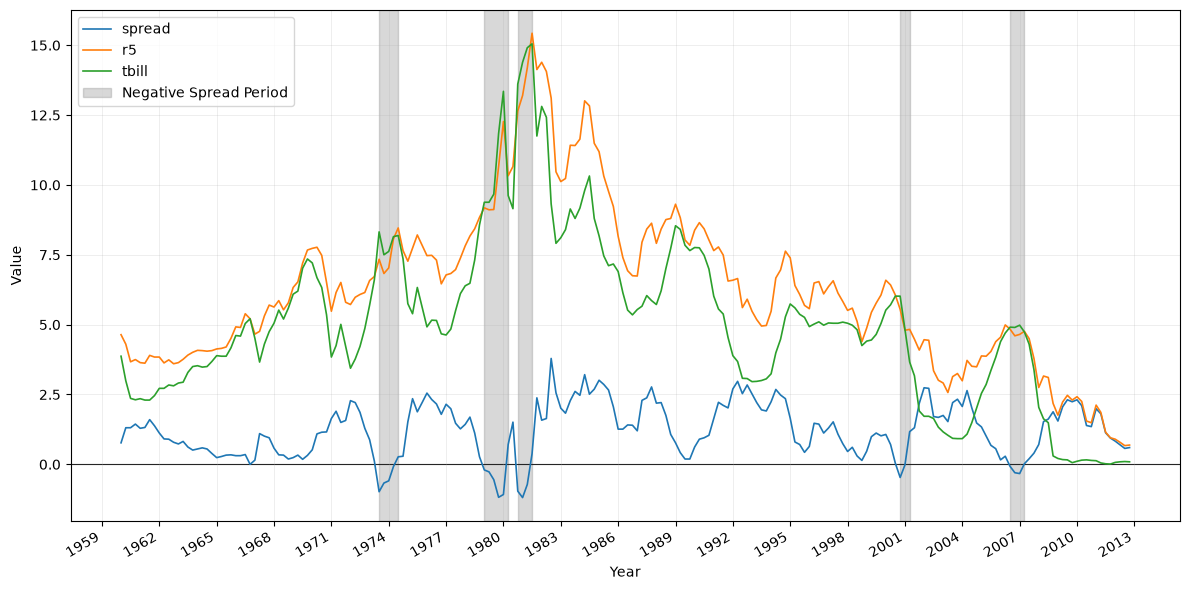

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 6))

# 複数の時系列を重ねて描画
for col in data_spread.columns:
    ax.plot(data_spread.index, data_spread[col], label=col, linewidth=1.2)

# y = 0 の水平線を描画
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-', zorder=1)

# 通常のグリッド
ax.grid(True, alpha=0.3, linewidth=0.5)

# x軸ラベルを３年ごとに配置
ax.xaxis.set_major_locator(mdates.YearLocator(3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# スプレッドが負の期間を強調
is_neg = data_spread['spread'] < 0  
change = is_neg.astype(int).diff().fillna(0)  # スプレッドが負から正に変わるときは1、正から負に変わるときは-1、それ以外は0
starts = data_spread.index[change == 1]
ends = data_spread.index[change == -1]

for start, end in zip(starts, ends):
    ax.axvspan(start, end, color='gray', alpha=0.3, zorder=0)  # axvspan メソッドは、指定した x 軸の範囲を塗る。

# 凡例の追加
neg_patch = mpatches.Patch(color='gray', alpha=0.3, label='Negative Spread Period')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles +[neg_patch], loc='best')
ax.set_xlabel('Year')
ax.set_ylabel('Value')
fig.autofmt_xdate()  # x軸のラベルを自動で回転

plt.tight_layout()
plt.show()

- 金利スプレッドの標本平均は 1.21 である。
- 一般的に、長期金利のほうが短期金利よりも高いため、スプレッドは正になることが多い。
- 長期金利、短期金利ともに上昇局面のときにスプレッドが負になることが多い。
- スプレッドの系列を見ると構造変化はないように見えるため、定常系列と考えてよさそうである。

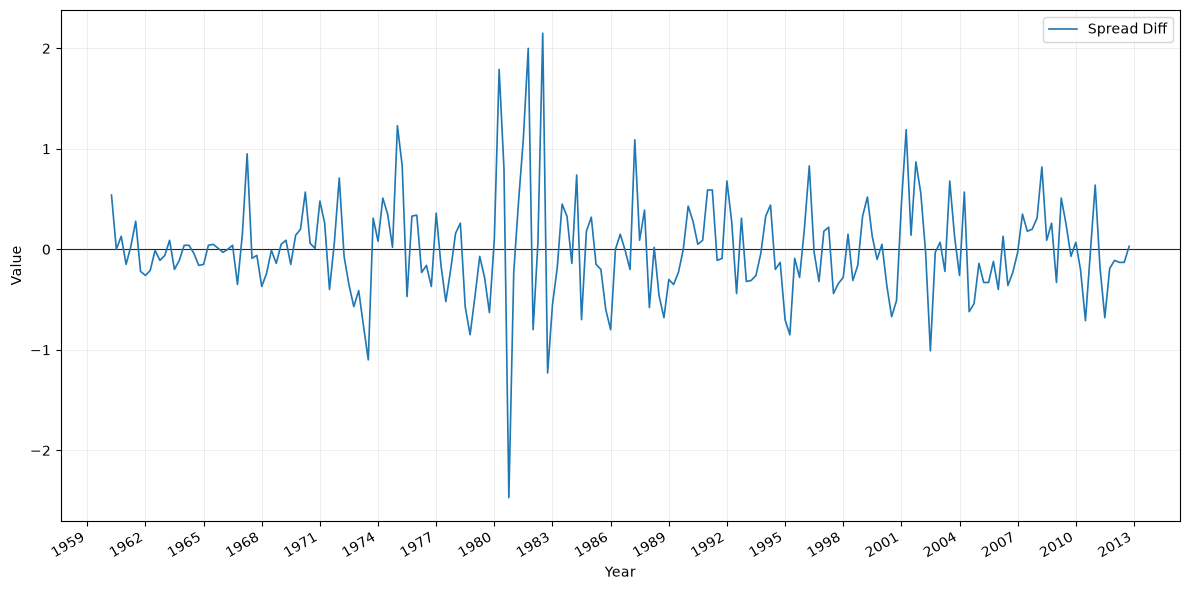

In [12]:
# スプレッドの階差を取ってみる

data_spread['spread_diff'] = data_spread['spread'].diff()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(data_spread.index, data_spread['spread_diff'], label='Spread Diff', linewidth=1.2)
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-', zorder=1)
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.xaxis.set_major_locator(mdates.YearLocator(3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='best')
ax.set_xlabel('Year')
ax.set_ylabel('Value')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


- スプレッドの1階の階差の動きはかなり不規則であり、重要な情報はなさそうである。したがって、階差を取る前のスプレッドの系列 $\{s_t\}$ を用いるほうが合理的。
- しかし、$s_t$ には大きな正（負）のジャンプが存在しているため、DGPが正規分布である仮定は妥当ではない可能性がある。
- したがって、分析者によってはそうした変動を小さくする変換を望むかもしれない。例えば、対数や平方根を取ると大きな値は小さく、小さな値は大きく評価されるため、変動は全体的に小さくなる。
- しかし、$s_t$ は負にもなりえるので、そのままでは対数変換や平方根変換はできない。そこで、正の定数 $c$ を用いて、すべての $t$ について $s_t + c > 0$ となるように $\ln (s_t + c)$ もしくは $(s_t + c)^{1/2}$ とすれば変換は可能となる。$s_t$ の図をみると $c=3$ とすればよい。
- データ分析の際は、DGPが前提条件を満たすかどうか確認する必要がある。

#### 同定（Identification）

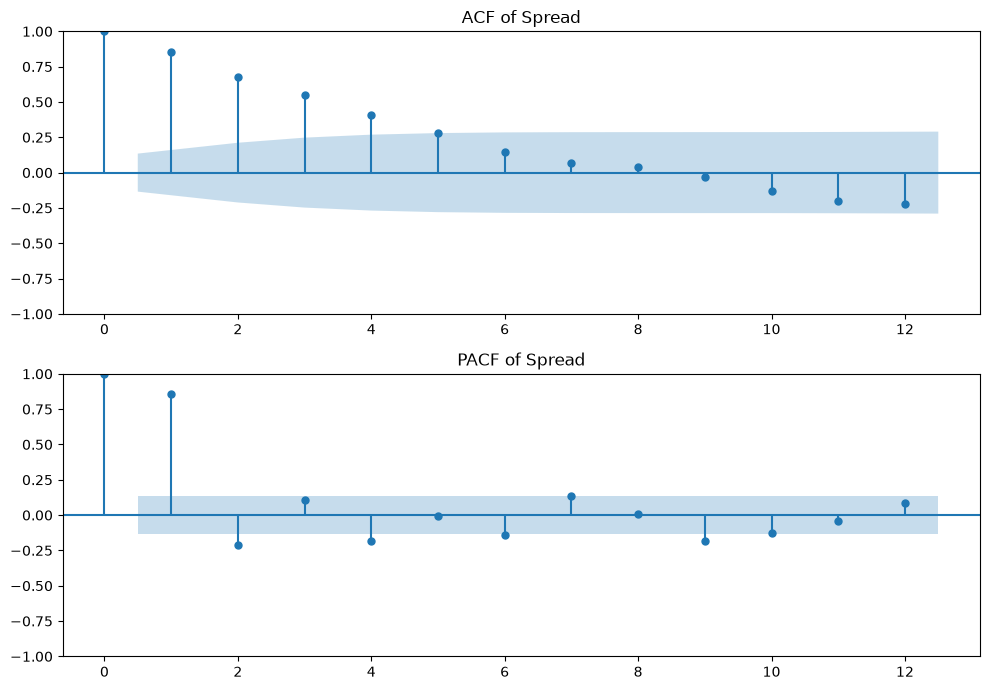

In [13]:
# ACFとPACFの描画

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1,figsize=(10, 7))  # 2行1列のサブプロットを作成, axesは2つのAxesオブジェクトの配列

plot_acf(data_spread['spread'].dropna(), lags=12, ax=axes[0])  
axes[0].set_title('ACF of Spread')

plot_pacf(data_spread['spread'].dropna(), lags=12, ax=axes[1], method='ywm')  # method='ywm'はYule-Walker法を使用してPACFを計算する
axes[1].set_title('PACF of Spread')

plt.tight_layout()
plt.show()

- 影付きの領域は、「真の自己相関が0である」という帰無仮説の下での95％信頼区間。バーがこの帯の外に出ている時点（ラグ）は、統計的に有意な自己相関がある（あるいはホワイトノイズでは説明できない構造がある）と判断される目安となる。  
- 理論上のACFとPACFの性質は以下である。  
  
|DGP|ACFの形状|PACFの形状|  
|---|---|---|  
|ホワイトノイズ|すべてのラグで自己相関ゼロ|すべてのラグで偏自己相関ゼロ|  
|AR(p)|緩やかに減衰。係数は振動するかもしれない|次数 $p$ で急激に打ち切り、それ以降は偏自己相関はゼロ|  
|MA(q)|次数 $q$ で急激に打ち切り|緩やかに減衰。係数は振動するかもしれない|  
|ARMA(p,q)|次数 $q+1$ から、一様もしくは振動しながら減衰する|次数 $p+1$ から、一様または振動しながら減衰する|  

- ACF は緩やかに減衰し、PACF は急激に打ち切られているので MA 過程やホワイトノイズではなさそうである。
- PACF をみると、次数1または2で急激に打ち切られているようにみえる。しかし、理論的にはそれ以降の偏自己相関がゼロになることを考えると次数4，6，7も含めて良さそうである。したがって、AR(p) 過程なら次数 $p$ は1,2,4,6,7あたりになると思われる。
- ARMA(p,q)過程に関しても ARMA(1,1),ARMA(2,1) あたりが良さそうである。

#### 推定（Estimation）

- 従属変数のラグ $(y_{t-1},y_{t-2},...)$ をモデルに含めると観測値が失われる。モデルの比較では、$T$ を固定しなければならない。さもなければ、異なる分析期間のモデル比較となってしまう。例えば、観測値が100個なら、AR(1), AR(2) モデルの推定では、最後の98個の観測値だけを用いる（$T=98$）。
- ここでは、1961Q4から2012Q4で統一した。

In [ ]:
# 金利スプレッドの推定



#### Appendix

##### matplotlib

matplotolib の描画は、次の３層のオブジェクト階層で構成されている。  
```mermaid
flowchart LR
    Figure --> Axes --> Artist
```
`Figure` は図全体のキャンパス、余白、サイズを管理する。`Axes` は一つのプロット領域の軸、目盛り、データ描画を管理する。`Artist` は実際に描かれる要素：Line2D, Text, Patch などを管理する。  


`fig, ax = plt.subplots()` を実行すると、`fig` は「紙全体」、`ax` は「その紙に置かれた一つのグラフ領域」を表す**オブジェクト**として返ってくる。  
重要なのは、`ax` が単なる関数の呼び出しの対象ではなく、状態（データ範囲、目盛り設定、描画済みの線のリストなど）を保持するオブジェクトであるという点。
<br>
|分類|役割|代表例|
|---|---|---|
|描画系|データから Artist を生成し追加する|`plot`,`scatter`,`bar`,`hist`,`fill_between`|
|設定系|Axes の属性（軸範囲、ラベル、目盛り）を読み書きする|`set_xlabel`,`set_ylim`,`set_title`|
|軸オブジェクト経由の詳細操作|`ax.xaxis`/`ax.yaxis` というサブオブジェクトを介した細かい制御|`ax.xaxis.set_major_locater(...)`|
|注釈・補助線系|データそのものではなく補助的な図形・文字を追加する|`axhline`,`axvline`,`annotate`,`text`,`axvspan`|  

スタンダードな型

```python
import matplotlib.pyplot as plt

# 1. Figure と Axes を作る（土台）
fig, ax = plt.subplots(figsize=(10, 5))

# 2. データを描画する（Artistを追加）
ax.plot(x, y, label='series A')

# 3. 軸・見た目を設定する（Axesの状態を調整）
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('title')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# 4. 仕上げ・出力
plt.tight_layout()
plt.show()  # または plt.savefig('out.png', dpi=300)
```

##### statsmodels

- ACF,PACF
<br>
`plot_acf`,`plot_pacf` の引数に `dropna()` が必要なのは、ACF・PACFの計算では階差を取ることによって系列の先頭に `NaN` を含んでしまうため。  
PACFの `method='ywm'` は計算方法に Yule-Walker法を指定している。ほかにもOLS法、Levinson-Durbin法などがある。  
statsmodels では信頼区間は、Bartlett's formula によって求められる。